# Reflection Pattern: Practice Exercise

Build a **Report Writing Agent** that uses the reflection pattern to iteratively improve content quality. This exercise reinforces using separate generation and reflection models, building reflection loops with controlled iterations, and implementing multi-step workflows in LangGraph.

**What you'll implement:**
- An outline generation node with reflection (max 2 iterations)
- A research node using Tavily web search
- A report writing node with reflection (max 2 iterations)

**Estimated time:** 20 minutes

In [1]:
!pip install langchain-core langchain-openai langgraph langchain-tavily  langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [2]:
import os
from functools import lru_cache

@lru_cache(maxsize=1)
def configure_environment(required_keys=None):
    """
    Factory function to configure environment variables.
    Executes once and caches results.
    """
    if required_keys is None:
        required_keys = ("OPENAI_API_KEY", )

    IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_TPU_ADDR' in os.environ

    if IN_COLAB:
        from google.colab import userdata
        print("Configuring for Google Colab environment...")
        for key in required_keys:
            try:
                os.environ[key] = userdata.get(key)
            except Exception:
                print(f"Warning: Could not find {key} in Colab secrets.")
    else:
        from dotenv import load_dotenv
        print("Configuring for local environment...")
        load_dotenv()

    # Validation
    for key in required_keys:
        if not os.getenv(key):
            raise ValueError(f"Missing required environment variable: {key}")

    return True

In [3]:
configure_environment(("OPENAI_API_KEY","TAVILY_API_KEY"))

Configuring for Google Colab environment...


True

## Setup

Run this cell to import all required libraries and configure the environment.

In [4]:
# Setup - run this cell first


from typing import TypedDict, List, Annotated
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_community.tools.tavily_search import TavilySearchResults
import operator

# Initialize models - using different models for generation vs reflection
generator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
reflector_llm = ChatOpenAI(model="gpt-4o", temperature=0)

# Initialize Tavily search tool
tavily_tool = TavilySearchResults(max_results=3)

# Constants
MAX_REFLECTION_ITERATIONS = 2

print("Setup complete!")
print(f"Generator model: gpt-4o-mini")
print(f"Reflector model: gpt-4o")
print(f"Max reflection iterations: {MAX_REFLECTION_ITERATIONS}")

Setup complete!
Generator model: gpt-4o-mini
Reflector model: gpt-4o
Max reflection iterations: 2


/tmp/ipykernel_4144/1936553950.py:16: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=3)


## Context

You are building a Report Writing Agent that produces high-quality research reports. The workflow uses the **reflection pattern** where a "reflector" model critiques the output of a "generator" model, enabling iterative improvement.

**Workflow:**
1. **Generate Outline** - Create a structured outline for the report topic
   - Reflection loop: Critique and improve the outline (max 2 iterations)
2. **Research** - Use Tavily to gather information for each outline section
3. **Write Report** - Write the full report based on outline and research
   - Reflection loop: Critique and improve the report (max 2 iterations)

**Reflection Pattern:**
- Generator creates content
- Reflector critiques and suggests improvements
- Generator incorporates feedback
- Repeat until max iterations or quality threshold

**Input:** A report topic (e.g., "The impact of AI on healthcare")

**Output:** A well-researched, refined report with:
- Clear structure from the outline
- Facts backed by web research
- Quality improved through reflection

---

## Part 1: Define the State

Define the state schema for the Report Writing Agent. Think about what data needs to flow through the workflow:

- The input topic
- Outline content and its reflection feedback/iteration count
- Research results
- Report content and its reflection feedback/iteration count
- Current workflow phase

In [5]:
class ReportState(TypedDict):
    """State schema for the Report Writing Agent."""

    # TODO: Define the state fields needed for this workflow
    # You'll need fields for:
    # - topic (str): The report topic from the user
    # - outline (str): Current outline (updated through reflection)
    # - outline_feedback (str): Reflection feedback on the outline
    # - outline_iterations (int): Number of outline reflection iterations completed
    # - research_results (str): Research results from Tavily
    # - report (str): Current report draft (updated through reflection)
    # - report_feedback (str): Reflection feedback on the report
    # - report_iterations (int): Number of report reflection iterations completed
    # - phase (str): Current phase: 'outline', 'research', 'writing', 'complete'

    # The report topic from the user
    topic: str
    # Current outline (updated through the reflection)
    outline: str
    #  Reflection feedback on the outline
    outline_feedback: str
    # Number of outline reflection iterations completed
    outline_iterations: int
    # Research results from Tavily
    research_results: str
    # Current report draft (updated through reflection)
    report: str
    # Reflection feedback on the report
    report_feedback: str
    # Number of report reflection iterations completed
    report_iterations: int
    # Current phase: 'outline', 'research', 'writing', 'complete'
    phase: str


print("State schema defined!")

State schema defined!


---

## Part 2: Implement the Outline Generation Node

Create a node that generates or improves an outline based on the topic. If there's feedback from the reflector, incorporate it to improve the outline.

In [21]:
def generate_outline(state: ReportState) -> dict:
    """
    Generates or improves a report outline based on the topic.

    If outline_feedback exists, incorporates it to improve the existing outline.
    Otherwise, generates a fresh outline from the topic.

    Args:
        state: Current workflow state containing topic, outline, and feedback

    Returns:
        dict with updated 'outline' and 'phase' set to 'outline'
    """
    topic = state["topic"]
    current_outline = state.get("outline", "")
    feedback = state.get("outline_feedback", "")
    iterations = state.get("outline_iterations", 0)

    print(f"\nGenerating outline (iteration {iterations + 1})...")

    # TODO: Implement outline generation
    # 1. Create a system prompt for outline generation
    #    - If feedback exists, instruct the model to improve the outline based on feedback
    #    - If no feedback, instruct to create a new outline
    # 2. Create user content with the topic and optionally current outline + feedback
    # 3. Call generator_llm.invoke() with the messages
    # 4. Return dict with 'outline' and 'phase': 'outline'

    if feedback :
      system_prompt = """ you are report generation expert and improve the report outline based on the topic.
                          TOverall structure should be maintained while address the feedback points
                          Keep the outline professional, well-organized, and factually accurate.
                          Return only the improved outline."""
      user_content = f"""Topic: {topic}
      Current Outline:
      {current_outline}

      Feedback to address:
      {feedback}

      Improve the outline based on this feedback."""
      messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]
    else:
      system_prompt = """ you are report generation expert and generate a detailed report outline based on the given topic.
      Include:
      - Introducion section
      - 3-4 main sections with sub-sections
      - Conclusion section
      Keep the outline professional, well-organized, and factually accurate.

      """
      user_content = f"""Topic: {topic}

      Generate a detailed report outline based on this topic."""
      messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]
    response = generator_llm.invoke(messages)
    outline = response.content.strip()
    print(f"Outline generated( {len(outline)} characters)")
    return {
        "outline": outline,
        "phase": "outline"
    }

    print("generate_outline node created!")

---

## Part 3: Implement the Outline Reflection Node

Create a node that critiques the outline and provides actionable feedback for improvement.

In [7]:
def reflect_on_outline(state: ReportState) -> dict:
    """
    Critiques the current outline and provides feedback for improvement.

    Uses the reflector model (gpt-4o) to analyze the outline and suggest
    specific improvements to structure, coverage, and organization.

    Args:
        state: Current workflow state containing the outline

    Returns:
        dict with 'outline_feedback' and incremented 'outline_iterations'
    """
    outline = state["outline"]
    topic = state["topic"]
    iterations = state.get("outline_iterations", 0)

    print(f"\nReflecting on outline (iteration {iterations + 1})...")

    # TODO: Implement outline reflection
    # 1. Create a system prompt for the reflector to critique the outline
    #    - Focus on: structure, coverage of topic, logical flow, missing sections
    # 2. Create user content with the topic and current outline
    # 3. Call reflector_llm.invoke() with the messages
    # 4. Return dict with 'outline_feedback' and 'outline_iterations': iterations + 1

    system_prompt = """ you are expert report reviewer, review the report outline based on the topic.
    Ensure the structure of the report is maintained.
    Check the coverage topic is complete or are there any missing sections, sections are organized in logical order.
    Keep the outline professional, well-organized, and factually accurate.
    Provide 3-5 suggestions to improve, Be constructive, encourage and precise
    """
    user_prompt = """   Topic: {topic}

    Outline to review:
    {outline}
    """
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]
    response = reflector_llm.invoke(messages)
    outline_feedback = response.content.strip()
    print(f"Outline feedback generated with {len(outline_feedback)} characters")
    return {
        "outline_feedback": outline_feedback,
        "outline_iterations": iterations + 1
    }

print("reflect_on_outline node created!")

reflect_on_outline node created!


---

## Part 4: Implement the Research Node (Provided)

This node uses Tavily to gather research information based on the outline sections.

In [8]:
def conduct_research(state: ReportState) -> dict:
    """
    Uses Tavily to research information for the report based on the outline.
    Extracts key topics from the outline and searches for relevant information.
    """
    topic = state["topic"]
    outline = state["outline"]

    print("\nConducting research...")

    # Generate search queries based on topic and outline
    query_prompt = f"""Based on this report topic and outline, generate 3 specific search queries
to gather relevant information. Return only the queries, one per line.

Topic: {topic}

Outline:
{outline}"""

    query_response = generator_llm.invoke([HumanMessage(content=query_prompt)])
    queries = query_response.content.strip().split("\n")[:3]

    # Search for each query
    all_results = []
    for query in queries:
        query = query.strip()
        if query:
            print(f"  Searching: {query[:50]}...")
            try:
                results = tavily_tool.invoke({"query": query})
                for result in results:
                    all_results.append(f"Source: {result.get('url', 'N/A')}\n{result.get('content', '')}")
            except Exception as e:
                print(f"  Search failed: {e}")

    research_text = "\n\n---\n\n".join(all_results) if all_results else "No research results found."

    print(f"  Found {len(all_results)} research results")

    return {
        "research_results": research_text,
        "phase": "research"
    }


print("conduct_research node created!")

conduct_research node created!


---

## Part 5: Report Writing Node (Provided)

This node writes or improves the report based on the outline and research. Study how it handles feedback for iterative improvement.

In [9]:
def write_report(state: ReportState) -> dict:
    """
    Writes or improves the report based on outline and research.

    If report_feedback exists, incorporates it to improve the existing report.
    Otherwise, generates a fresh report from the outline and research.
    """
    topic = state["topic"]
    outline = state["outline"]
    research = state["research_results"]
    current_report = state.get("report", "")
    feedback = state.get("report_feedback", "")
    iterations = state.get("report_iterations", 0)

    print(f"\nWriting report (iteration {iterations + 1})...")

    # Create appropriate system prompt based on whether we have feedback
    if feedback:
        system_prompt = """You are an expert report writer. Improve the given report based on the feedback provided.
Maintain the overall structure but address all the feedback points.
Keep the report professional, well-organized, and factually accurate.
Return only the improved report."""

        user_content = f"""Topic: {topic}

Current Report:
{current_report}

Feedback to address:
{feedback}

Please improve the report based on this feedback."""
    else:
        system_prompt = """You are an expert report writer. Write a comprehensive report following the given outline.
Use the research results to support your points with facts and data.
Make the report professional, well-organized, and engaging.
Include an introduction, body sections following the outline, and a conclusion."""

        user_content = f"""Topic: {topic}

Outline to follow:
{outline}

Research results to incorporate:
{research[:3000]}...

Please write a comprehensive report based on this outline and research."""

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    response = generator_llm.invoke(messages)
    report = response.content.strip()

    print(f"Report written ({len(report)} characters)")

    return {
        "report": report,
        "phase": "writing"
    }


print("write_report node created!")

write_report node created!


---

## Part 6: Implement the Report Reflection Node

Create a node that critiques the report and provides actionable feedback.

In [10]:
def reflect_on_report(state: ReportState) -> dict:
    """
    Critiques the current report and provides feedback for improvement.

    Uses the reflector model (gpt-4o) to analyze the report and suggest
    specific improvements to clarity, accuracy, and completeness.

    Args:
        state: Current workflow state containing the report

    Returns:
        dict with 'report_feedback' and incremented 'report_iterations'
    """
    report = state["report"]
    topic = state["topic"]
    outline = state["outline"]
    iterations = state.get("report_iterations", 0)

    print(f"\nReflecting on report (iteration {iterations + 1})...")

    # TODO: Implement report reflection
    # 1. Create a system prompt for the reflector to critique the report
    #    - Focus on: clarity, accuracy, completeness, adherence to outline
    # 2. Create user content with the topic, outline, and current report
    # 3. Call reflector_llm.invoke() with the messages
    # 4. Return dict with 'report_feedback' and 'report_iterations': iterations + 1

    system_prompt = """ you are expert report reviewer, Analyze the report and provide specific actionable feedback.

    Clarity: Ensure the report is clear on details and easy to understand
    Accuracy:Are the claims supported by  evidences
    Completeness: Check the coverage of topic is complete or are there any missing sections
    Structure: Are the sections following logical order

    Provide 3-5 suggestions to improve, Be constructive, encourage and precise
    """
    user_prompt = """   Topic: {topic}

    Original Outline:
    {outline}
    Report to review:
    {report[:4000]}
    Provide specific feedback for improving the report.
    """
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_prompt)
    ]
    response = reflector_llm.invoke(messages)
    report_feedback = response.content.strip()
    print(f"Report feedback generated with {len(report_feedback)} characters")
    return {
        "report_feedback": report_feedback,
        "report_iterations": iterations + 1
    }


print("reflect_on_report node created!")

reflect_on_report node created!


---

## Part 6a: Output Generation Node (Provided)

This node generates the final formatted output summary after all reflections are complete.

In [11]:
def generate_output(state: ReportState) -> dict:
    """
    Generates a final formatted output with summary statistics about the workflow.
    This node runs after all reflections are complete.
    """
    topic = state["topic"]
    outline = state["outline"]
    report = state["report"]
    outline_iterations = state.get("outline_iterations", 0)
    report_iterations = state.get("report_iterations", 0)

    print("\n" + "=" * 60)
    print("GENERATING FINAL OUTPUT")
    print("=" * 60)

    # Generate a brief executive summary
    summary_prompt = f"""Based on this report, write a 2-3 sentence executive summary that captures the key insights.

Report:
{report[:2000]}...

Return only the executive summary, nothing else."""

    response = generator_llm.invoke([HumanMessage(content=summary_prompt)])
    executive_summary = response.content.strip()

    # Create formatted output
    output = f"""
{'='*60}
REPORT GENERATION COMPLETE
{'='*60}

Topic: {topic}

Executive Summary:
{executive_summary}

Statistics:
- Outline iterations: {outline_iterations}
- Report iterations: {report_iterations}
- Outline length: {len(outline)} characters
- Report length: {len(report)} characters

{'='*60}
"""

    print(output)

    return {
        "phase": "complete"
    }


print("generate_output node created!")

generate_output node created!


---

## Part 7: Define Routing Logic

Implement the conditional routing functions that control the reflection loops.

In [27]:
def route_after_outline_reflection(state: ReportState) -> str:
    """
    Determines whether to continue refining the outline or move to research.

    Returns:
        'generate_outline' if more iterations needed (< MAX_REFLECTION_ITERATIONS)
        'conduct_research' if max iterations reached
    """
    # TODO: Implement routing logic
    # Check outline_iterations against MAX_REFLECTION_ITERATIONS
    # Return appropriate node name

    iterations = state.get('outline_iterations', 0) # Corrected key from 'outline_reflections'
    if iterations < MAX_REFLECTION_ITERATIONS:
      print(f"Refinement in progress (iteration {iterations + 1}/{MAX_REFLECTION_ITERATIONS})")
      return "generate_outline"
    else:
      print(f"MAX Iterations {MAX_REFLECTION_ITERATIONS} completed for outline, moving to research")
      return "conduct_research"


def route_after_report_reflection(state: ReportState) -> str:
    """
    Determines whether to continue refining the report or move to output generation.

    Returns:
        'write_report' if more iterations needed (< MAX_REFLECTION_ITERATIONS)
        'generate_output' if max iterations reached
    """
    # TODO: Implement routing logic
    # Check report_iterations against MAX_REFLECTION_ITERATIONS
    # Return appropriate node name

    report_iterations = state.get('report_iterations', 0)
    if report_iterations < MAX_REFLECTION_ITERATIONS:
      print(f"Report generation in progress (iteration {report_iterations + 1}/{MAX_REFLECTION_ITERATIONS})")
      return "write_report"
    else:
      print(f"MAX Iterations {MAX_REFLECTION_ITERATIONS} completed for report, generating output")
      return "generate_output"



print("Routing functions defined!")

Routing functions defined!


---

## Part 8: Build and Compile the Graph

Wire everything together into a complete workflow with reflection loops.

In [28]:
# Build the graph
workflow = StateGraph(ReportState)

# Add nodes
workflow.add_node("generate_outline", generate_outline)
workflow.add_node("reflect_outline", reflect_on_outline)
workflow.add_node("conduct_research", conduct_research)
workflow.add_node("write_report", write_report)
workflow.add_node("reflect_report", reflect_on_report)
workflow.add_node("generate_output", generate_output)

# Add edges for outline phase
workflow.add_edge(START, "generate_outline")
workflow.add_edge("generate_outline", "reflect_outline")
workflow.add_conditional_edges(
    "reflect_outline",
    route_after_outline_reflection,
    {
        "generate_outline": "generate_outline",
        "conduct_research": "conduct_research"
    }
)

# Add edges for research -> writing phase
workflow.add_edge("conduct_research", "write_report")
workflow.add_edge("write_report", "reflect_report")
workflow.add_conditional_edges(
    "reflect_report",
    route_after_report_reflection,
    {
        "write_report": "write_report",
        "generate_output": "generate_output"
    }
)

# Add final edge from output to END
workflow.add_edge("generate_output", END)

# Compile the graph
app = workflow.compile()

print("Graph compiled!")
print("\nWorkflow structure:")
print("  START -> generate_outline <-> reflect_outline (max 2 iterations)")
print("    -> conduct_research")
print("    -> write_report <-> reflect_report (max 2 iterations)")
print("    -> generate_output -> END")

Graph compiled!

Workflow structure:
  START -> generate_outline <-> reflect_outline (max 2 iterations)
    -> conduct_research
    -> write_report <-> reflect_report (max 2 iterations)
    -> generate_output -> END


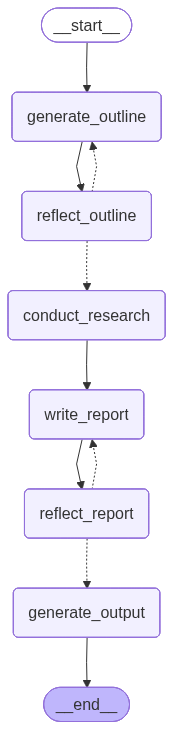

In [29]:
# Visualize the graph (optional)
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Visualization not available: {e}")

---

## Run Your Implementation

Test the reflection workflow with a sample report topic.

In [30]:
# Run the report writing workflow
print("Starting Report Writing Agent")
print("=" * 60)

initial_state = {
    "topic": "The impact of renewable energy on global economics",
    "outline": "",
    "outline_feedback": "",
    "outline_iterations": 0,
    "research_results": "",
    "report": "",
    "report_feedback": "",
    "report_iterations": 0,
    "phase": "outline"
}

# Run the workflow
final_state = app.invoke(initial_state)

print("\n" + "=" * 60)
print("WORKFLOW COMPLETE")
print("=" * 60)

Starting Report Writing Agent

Generating outline (iteration 1)...
Outline generated( 3009 characters)

Reflecting on outline (iteration 1)...
Outline feedback generated with 3128 characters
Refinement in progress (iteration 2/2)

Generating outline (iteration 2)...
Outline generated( 3567 characters)

Reflecting on outline (iteration 2)...
Outline feedback generated with 2499 characters
MAX Iterations 2 completed for outline, moving to research

Conducting research...
  Searching: 1. "impact of renewable energy on global economy 2...
  Searching: 2. "job creation and economic benefits of renewabl...
  Searching: 3. "challenges in renewable energy adoption and in...
  Found 9 research results

Writing report (iteration 1)...
Report written (13917 characters)

Reflecting on report (iteration 1)...
Report feedback generated with 89 characters
Report generation in progress (iteration 2/2)

Writing report (iteration 2)...
Report written (13917 characters)

Reflecting on report (iteration 2

In [31]:
# Display the final outline
print("FINAL OUTLINE")
print("=" * 60)
print(final_state["outline"])

FINAL OUTLINE
# Report Outline: The Impact of Renewable Energy on Global Economics

## Introduction
   - A. Definition of Renewable Energy
   - B. Overview of Global Energy Landscape
   - C. Importance of Renewable Energy in Contemporary Economics
   - D. Purpose and Scope of the Report

## Section 1: The Current State of Renewable Energy
   - A. Global Energy Consumption Trends
      1. Statistics on Energy Sources (Fossil Fuels vs. Renewables)
      2. Growth Rates of Renewable Energy Sectors
   - B. Technological Advancements in Renewable Energy
      1. Innovations in Solar, Wind, Hydro, and Biomass Energy
      2. Role of Energy Storage Solutions
   - C. Major Players in the Renewable Energy Market
      1. Leading Countries in Renewable Energy Production
      2. Key Companies and Their Market Share

## Section 2: Economic Benefits of Renewable Energy
   - A. Job Creation and Economic Growth
      1. Employment Opportunities in the Renewable Sector
      2. Economic Multiplier Ef

In [32]:
# Display the final report
print("FINAL REPORT")
print("=" * 60)
print(final_state["report"])

FINAL REPORT
# The Impact of Renewable Energy on Global Economics

## Introduction

### A. Definition of Renewable Energy
Renewable energy refers to energy derived from natural processes that are replenished at a rate faster than they are consumed. Common sources include solar, wind, hydroelectric, biomass, and geothermal energy. These energy forms are considered sustainable alternatives to fossil fuels, which are finite and contribute significantly to greenhouse gas emissions.

### B. Overview of Global Energy Landscape
As of 2021, fossil fuels accounted for approximately 78.9% of the world's total final energy consumption (TFEC), a slight decrease from 81.2% in 2011. In contrast, modern renewable energy's share has grown significantly, increasing from 30 exajoules (EJ) in 2011 to 50 EJ in 2021, showcasing a steady shift towards cleaner energy sources. Despite fluctuations in global energy consumption, the transition to renewables remains a pivotal focus for governments and industries

---

## Expected Output

If your implementation is correct, you should see:

**Outline Phase (2 iterations):**
```
Generating outline (iteration 1)...
Reflecting on outline (iteration 1)...
Generating outline (iteration 2)...
Reflecting on outline (iteration 2)...
```

**Research Phase:**
```
Conducting research...
  Searching: [query 1]...
  Searching: [query 2]...
  Searching: [query 3]...
  Found X research results
```

**Writing Phase (2 iterations):**
```
Writing report (iteration 1)...
Reflecting on report (iteration 1)...
Writing report (iteration 2)...
Reflecting on report (iteration 2)...
```

**Final Output:**
- A well-structured outline with multiple sections
- A comprehensive report that follows the outline and incorporates research